# INbreast Dataset Preprocessing for External Validation

## Purpose

This notebook preprocesses the INbreast dataset with a simplified pipeline:
- **Artifact Removal**: Remove labels/markers from mammograms
- **CLAHE**: Contrast-Limited Adaptive Histogram Equalization
- **High Resolution**: Preserve original resolution for Stage 4 models

### Why External Validation Matters

External validation on an independent dataset is crucial for:
1. **Generalization Assessment**: Testing if models trained on CBIS-DDSM generalize
2. **Bias Detection**: Identifying potential overfitting to dataset-specific artifacts
3. **Clinical Relevance**: INbreast contains higher-quality digital mammograms

### Dataset Information

**INbreast Dataset (Moreira et al., 2012)**:
- 410 full-field digital mammography images
- Acquired at Centro Hospitalar de S. João, Porto, Portugal
- BI-RADS classifications from expert radiologists
- Higher image quality than CBIS-DDSM (direct digital acquisition)

### Literature References

1. **Moreira et al. (2012)** - "INbreast: Toward a Full-field Digital Mammographic Database"
2. **Pizer et al. (1987)** - "Adaptive Histogram Equalization and Its Variations" - CLAHE algorithm

## 1. Setup and Imports

In [1]:
import os
import sys
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, field
from collections import defaultdict
import json
from datetime import datetime
import time

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import pydicom

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

print("INBREAST PREPROCESSING ENVIRONMENT")
print("=" * 60)
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"PyDicom version: {pydicom.__version__}")
print("\nAll imports successful!")

INBREAST PREPROCESSING ENVIRONMENT
Python version: 3.13.5
NumPy version: 2.1.3
Pandas version: 2.2.3
OpenCV version: 4.12.0
PyDicom version: 3.0.1

All imports successful!


## 2. Configuration

In [2]:
@dataclass
class INbreastPreprocessingConfig:
    """Configuration for simplified INbreast preprocessing."""
    
    # Input paths
    inbreast_root: str = r'D:\Project\data\INbreast'
    dicom_dir: str = r'D:\Project\data\INbreast\AllDICOMs'
    csv_path: str = r'D:\Project\data\INbreast\INbreast.csv'
    
    # Output paths
    output_dir: str = r'D:\Project\data\inbreast_preprocessed'
    
    # Image processing - SIMPLIFIED PIPELINE
    target_size: Tuple[int, int] = (768, 768)  # High resolution for Stage 4
    clahe_clip_limit: float = 2.0
    clahe_tile_grid: Tuple[int, int] = (8, 8)
    
    # Only two operations enabled
    remove_artifacts: bool = True   # Remove labels/markers
    apply_clahe: bool = True        # Contrast enhancement
    
    # BI-RADS to binary label mapping
    # BI-RADS 1, 2, 3 -> Benign (0)
    # BI-RADS 4a, 4b, 4c, 5, 6 -> Malignant (1)
    benign_birads: List[str] = field(default_factory=lambda: ['1', '2', '3'])
    malignant_birads: List[str] = field(default_factory=lambda: ['4a', '4b', '4c', '5', '6', '4'])

config = INbreastPreprocessingConfig()

print("SIMPLIFIED PREPROCESSING CONFIGURATION")
print("=" * 60)
print(f"Input DICOM Directory: {config.dicom_dir}")
print(f"Metadata CSV: {config.csv_path}")
print(f"Output Directory: {config.output_dir}")
print(f"\nPreprocessing Pipeline:")
print(f"  - Artifact Removal: {config.remove_artifacts}")
print(f"  - CLAHE: {config.apply_clahe} (clip={config.clahe_clip_limit})")
print(f"  - Target Size: {config.target_size}")
print("=" * 60)

SIMPLIFIED PREPROCESSING CONFIGURATION
Input DICOM Directory: D:\Project\data\INbreast\AllDICOMs
Metadata CSV: D:\Project\data\INbreast\INbreast.csv
Output Directory: D:\Project\data\inbreast_preprocessed

Preprocessing Pipeline:
  - Artifact Removal: True
  - CLAHE: True (clip=2.0)
  - Target Size: (768, 768)


## 3. Data Structures and Loading

In [3]:
@dataclass
class INbreastRecord:
    """Data structure for INbreast image record."""
    file_name: str
    patient_id: str
    laterality: str  # L or R
    view: str  # CC or MLO
    birads: str
    label: str  # benign or malignant
    label_binary: int  # 0 or 1
    dicom_path: str

@dataclass
class PreprocessingStats:
    """Statistics tracking for preprocessing."""
    total_images: int = 0
    processed: int = 0
    skipped: int = 0
    errors: int = 0
    benign_count: int = 0
    malignant_count: int = 0
    
    def summary(self) -> str:
        return (
            f"Total: {self.total_images} | "
            f"Processed: {self.processed} | "
            f"Skipped: {self.skipped} | "
            f"Errors: {self.errors} | "
            f"Benign: {self.benign_count} | "
            f"Malignant: {self.malignant_count}"
        )

def load_inbreast_metadata(config: INbreastPreprocessingConfig) -> List[INbreastRecord]:
    """Load and parse INbreast metadata CSV."""
    print("Loading INbreast metadata...")
    
    # Read CSV (semicolon-delimited)
    df = pd.read_csv(config.csv_path, sep=';')
    print(f"  Found {len(df)} entries in CSV")
    print(f"  Columns: {list(df.columns)}")
    
    # Get list of DICOM files
    dicom_files = list(Path(config.dicom_dir).glob('*.dcm'))
    print(f"  Found {len(dicom_files)} DICOM files")
    
    # Create file name mapping
    dicom_map = {f.stem: str(f) for f in dicom_files}
    
    records = []
    skipped_birads = defaultdict(int)
    
    for _, row in df.iterrows():
        # Get file name from the 'File Name' column
        file_name = str(row['File Name']).strip()
        
        # Find corresponding DICOM file
        dicom_path = None
        for key, path in dicom_map.items():
            if file_name in key or key in file_name:
                dicom_path = path
                break
        
        if not dicom_path:
            continue
        
        # Parse BI-RADS
        birads = str(row['Bi-Rads']).strip().lower()
        
        # Map BI-RADS to binary label
        if birads in [b.lower() for b in config.benign_birads]:
            label = 'benign'
            label_binary = 0
        elif birads in [b.lower() for b in config.malignant_birads]:
            label = 'malignant'
            label_binary = 1
        else:
            skipped_birads[birads] += 1
            continue
        
        # Parse laterality and view
        laterality = str(row['Laterality']).strip().upper()
        view = str(row['View']).strip().upper()
        
        record = INbreastRecord(
            file_name=file_name,
            patient_id=str(row['Patient Id']).strip() if 'Patient Id' in df.columns else 'unknown',
            laterality=laterality,
            view=view,
            birads=birads,
            label=label,
            label_binary=label_binary,
            dicom_path=dicom_path
        )
        records.append(record)
    
    print(f"\n  Loaded {len(records)} valid records")
    if skipped_birads:
        print(f"  Skipped BI-RADS: {dict(skipped_birads)}")
    
    # Count by label
    benign = sum(1 for r in records if r.label == 'benign')
    malignant = sum(1 for r in records if r.label == 'malignant')
    print(f"  Class distribution: Benign={benign}, Malignant={malignant}")
    
    return records

# Load metadata
records = load_inbreast_metadata(config)

Loading INbreast metadata...
  Found 410 entries in CSV
  Columns: ['Patient ID', 'Patient age', 'Laterality', 'View', 'Acquisition date', 'File Name', 'ACR', 'Bi-Rads']
  Found 410 DICOM files

  Loaded 410 valid records
  Class distribution: Benign=310, Malignant=100


## 4. Simplified Preprocessing Functions

In [4]:
def read_dicom(path: str) -> Optional[np.ndarray]:
    """Read DICOM file and return pixel array."""
    try:
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)
        
        # Handle MONOCHROME1 (inverted) images
        if hasattr(dcm, 'PhotometricInterpretation'):
            if dcm.PhotometricInterpretation == 'MONOCHROME1':
                img = img.max() - img
        
        # Normalize to 0-255
        if img.max() > img.min():
            img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
        else:
            img = np.zeros_like(img, dtype=np.uint8)
        
        return img
    except Exception as e:
        print(f"Error reading DICOM {path}: {e}")
        return None


def remove_artifacts(img: np.ndarray) -> np.ndarray:
    """
    Remove labels, markers, and other artifacts from mammogram.
    
    Uses morphological operations to identify and remove small bright regions
    that are likely to be labels or markers.
    
    Reference: Shen et al. (2019) preprocessing pipeline
    """
    # Threshold to find bright regions
    _, thresh = cv2.threshold(img, 250, 255, cv2.THRESH_BINARY)
    
    # Find connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=8)
    
    # Create mask for artifacts (small bright regions)
    artifact_mask = np.zeros_like(img, dtype=np.uint8)
    total_area = img.shape[0] * img.shape[1]
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        # Artifacts are typically small (< 1% of image)
        if area < total_area * 0.01:
            artifact_mask[labels == i] = 255
    
    # Inpaint artifacts
    if np.any(artifact_mask):
        img = cv2.inpaint(img, artifact_mask, 3, cv2.INPAINT_TELEA)
    
    return img


def apply_clahe_enhancement(img: np.ndarray, config: INbreastPreprocessingConfig) -> np.ndarray:
    """
    Apply Contrast-Limited Adaptive Histogram Equalization (CLAHE).
    
    CLAHE enhances local contrast while limiting noise amplification.
    
    Reference: Pizer et al. (1987)
    """
    clahe = cv2.createCLAHE(
        clipLimit=config.clahe_clip_limit,
        tileGridSize=config.clahe_tile_grid
    )
    return clahe.apply(img)


def resize_with_padding(img: np.ndarray, target_size: Tuple[int, int]) -> np.ndarray:
    """
    Resize image to target size with reflection padding to preserve aspect ratio.
    """
    h, w = img.shape[:2]
    target_h, target_w = target_size
    
    # Calculate scale to fit within target
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Resize
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    
    # Pad to target size with reflection
    pad_w = target_w - new_w
    pad_h = target_h - new_h
    
    left = pad_w // 2
    right = pad_w - left
    top = pad_h // 2
    bottom = pad_h - top
    
    padded = cv2.copyMakeBorder(
        resized, top, bottom, left, right,
        borderType=cv2.BORDER_REFLECT
    )
    
    return padded


def preprocess_image(img: np.ndarray, config: INbreastPreprocessingConfig) -> np.ndarray:
    """
    Apply simplified preprocessing pipeline:
    1. Artifact removal
    2. CLAHE
    3. Resize with padding
    """
    # Step 1: Remove artifacts
    if config.remove_artifacts:
        img = remove_artifacts(img)
    
    # Step 2: Apply CLAHE
    if config.apply_clahe:
        img = apply_clahe_enhancement(img, config)
    
    # Step 3: Resize with padding
    img = resize_with_padding(img, config.target_size)
    
    return img

print("Preprocessing functions defined!")
print("Pipeline: Artifact Removal -> CLAHE -> Resize with Padding")

Preprocessing functions defined!
Pipeline: Artifact Removal -> CLAHE -> Resize with Padding


## 5. Process All Images

In [5]:
def process_all_images(records: List[INbreastRecord], config: INbreastPreprocessingConfig) -> PreprocessingStats:
    """Process all INbreast images with simplified pipeline."""
    
    stats = PreprocessingStats(total_images=len(records))
    
    # Create output directories
    os.makedirs(os.path.join(config.output_dir, 'benign'), exist_ok=True)
    os.makedirs(os.path.join(config.output_dir, 'malignant'), exist_ok=True)
    
    # Process with progress bar
    pbar = tqdm(records, desc="Processing INbreast", ncols=140,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}')
    
    processed_records = []
    
    for record in pbar:
        pbar.set_postfix_str(f"File: {record.file_name[:20]}... | Label: {record.label}")
        
        try:
            # Read DICOM
            img = read_dicom(record.dicom_path)
            if img is None:
                stats.errors += 1
                continue
            
            # Preprocess
            processed = preprocess_image(img, config)
            
            # Create output filename
            output_name = f"{record.file_name}_{record.laterality}_{record.view}.png"
            output_path = os.path.join(config.output_dir, record.label, output_name)
            
            # Save
            cv2.imwrite(output_path, processed)
            
            # Update stats
            stats.processed += 1
            if record.label == 'benign':
                stats.benign_count += 1
            else:
                stats.malignant_count += 1
            
            # Store processed record info
            processed_records.append({
                'file_name': record.file_name,
                'patient_id': record.patient_id,
                'laterality': record.laterality,
                'view': record.view,
                'birads': record.birads,
                'label': record.label,
                'label_binary': record.label_binary,
                'output_path': output_path
            })
            
        except Exception as e:
            stats.errors += 1
            pbar.write(f"Error processing {record.file_name}: {e}")
    
    # Save metadata
    metadata_df = pd.DataFrame(processed_records)
    metadata_df.to_csv(os.path.join(config.output_dir, 'metadata.csv'), index=False)
    
    return stats, processed_records

# Process all images
print("\n" + "=" * 60)
print("STARTING PREPROCESSING")
print("=" * 60)
stats, processed_records = process_all_images(records, config)

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(stats.summary())


STARTING PREPROCESSING


Processing INbreast: 100%|████████████████████████████████████████████| 410/410 [00:51<00:00,  7.94it/s] , File: 24055806... | Label: benign


PREPROCESSING COMPLETE
Total: 410 | Processed: 410 | Skipped: 0 | Errors: 0 | Benign: 310 | Malignant: 100


## 6. Generate View Pairs for Multi-View Models

In [6]:
def generate_view_pairs(processed_records: List[Dict], config: INbreastPreprocessingConfig) -> pd.DataFrame:
    """
    Generate view pairs (CC + MLO) for multi-view model evaluation.
    """
    # Group by patient and laterality
    groups = defaultdict(lambda: {'CC': None, 'MLO': None, 'label': None, 'birads': None})
    
    for record in processed_records:
        key = (record['patient_id'], record['laterality'])
        view = record['view'].upper()
        if view in ['CC', 'MLO']:
            groups[key][view] = record['output_path']
            groups[key]['label'] = record['label']
            groups[key]['label_binary'] = record['label_binary']
            groups[key]['birads'] = record['birads']
    
    # Create pairs where both views exist
    pairs = []
    for (patient_id, laterality), data in groups.items():
        if data['CC'] and data['MLO']:
            pairs.append({
                'patient_id': patient_id,
                'laterality': laterality,
                'cc_path': data['CC'],
                'mlo_path': data['MLO'],
                'label': data['label'],
                'label_binary': data['label_binary'],
                'birads': data['birads']
            })
    
    # Save view pairs
    pairs_df = pd.DataFrame(pairs)
    pairs_path = os.path.join(config.output_dir, 'view_pairs.csv')
    pairs_df.to_csv(pairs_path, index=False)
    
    print(f"\nView Pairs Generated:")
    print(f"  Total pairs: {len(pairs)}")
    print(f"  Benign pairs: {sum(1 for p in pairs if p['label'] == 'benign')}")
    print(f"  Malignant pairs: {sum(1 for p in pairs if p['label'] == 'malignant')}")
    print(f"  Saved to: {pairs_path}")
    
    return pairs_df

# Generate view pairs
view_pairs_df = generate_view_pairs(processed_records, config)


View Pairs Generated:
  Total pairs: 2
  Benign pairs: 2
  Malignant pairs: 0
  Saved to: D:\Project\data\inbreast_preprocessed\view_pairs.csv


## 7. Visualization and Statistics

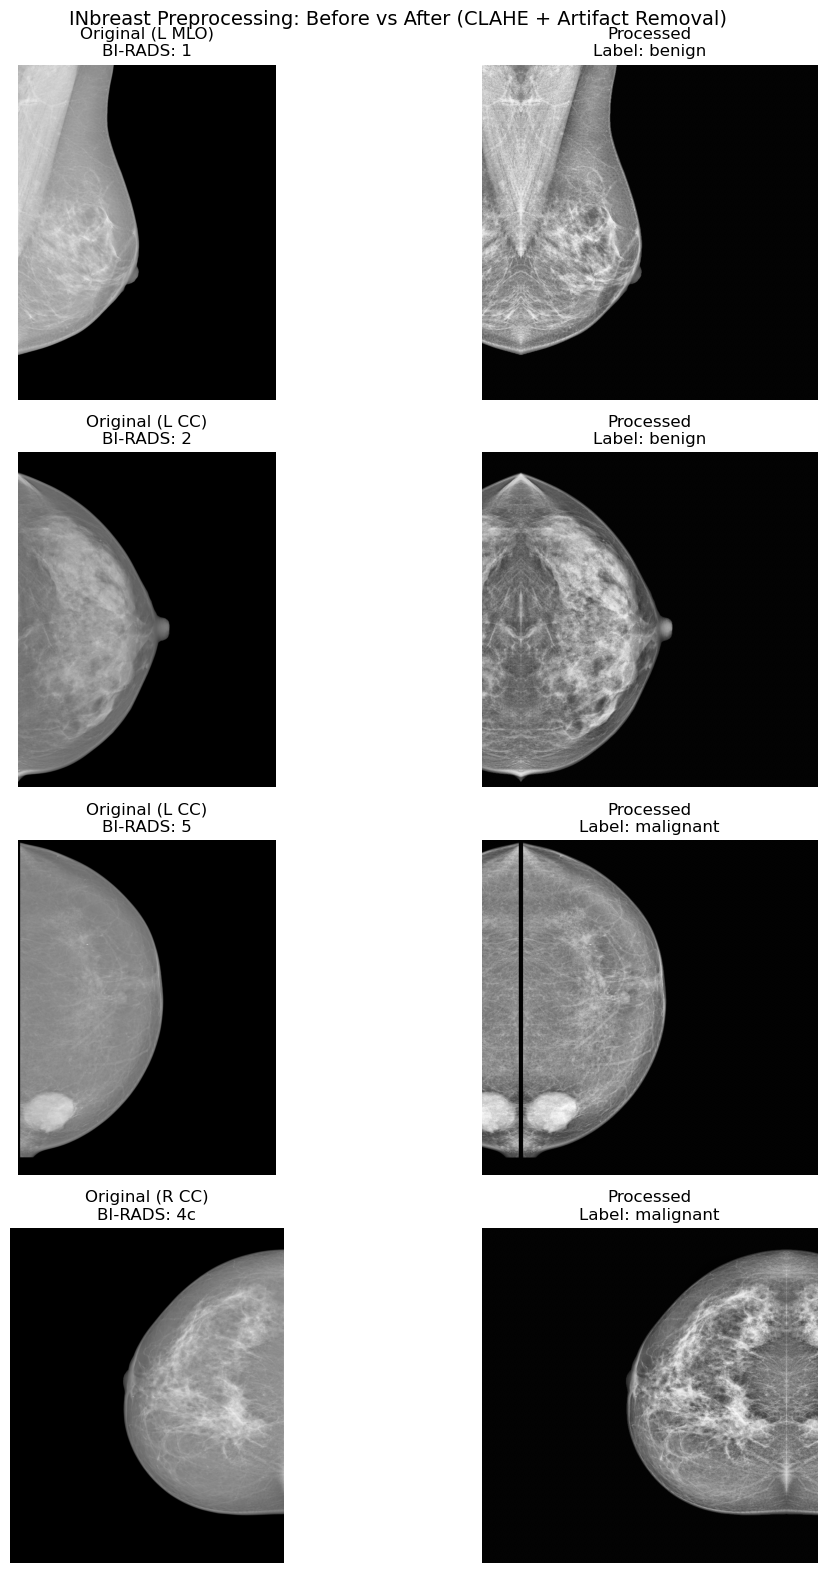

In [7]:
# Sample before/after visualization
def visualize_samples(records: List[INbreastRecord], config: INbreastPreprocessingConfig, n_samples: int = 4):
    """Visualize before/after preprocessing for sample images."""
    
    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4*n_samples))
    fig.suptitle('INbreast Preprocessing: Before vs After (CLAHE + Artifact Removal)', fontsize=14)
    
    # Sample random records
    sample_records = np.random.choice(records, min(n_samples, len(records)), replace=False)
    
    for i, record in enumerate(sample_records):
        # Read original
        original = read_dicom(record.dicom_path)
        if original is None:
            continue
        
        # Process
        processed = preprocess_image(original, config)
        
        # Plot
        axes[i, 0].imshow(original, cmap='gray')
        axes[i, 0].set_title(f'Original ({record.laterality} {record.view})\nBI-RADS: {record.birads}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(processed, cmap='gray')
        axes[i, 1].set_title(f'Processed\nLabel: {record.label}')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, 'preprocessing_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples(records, config)

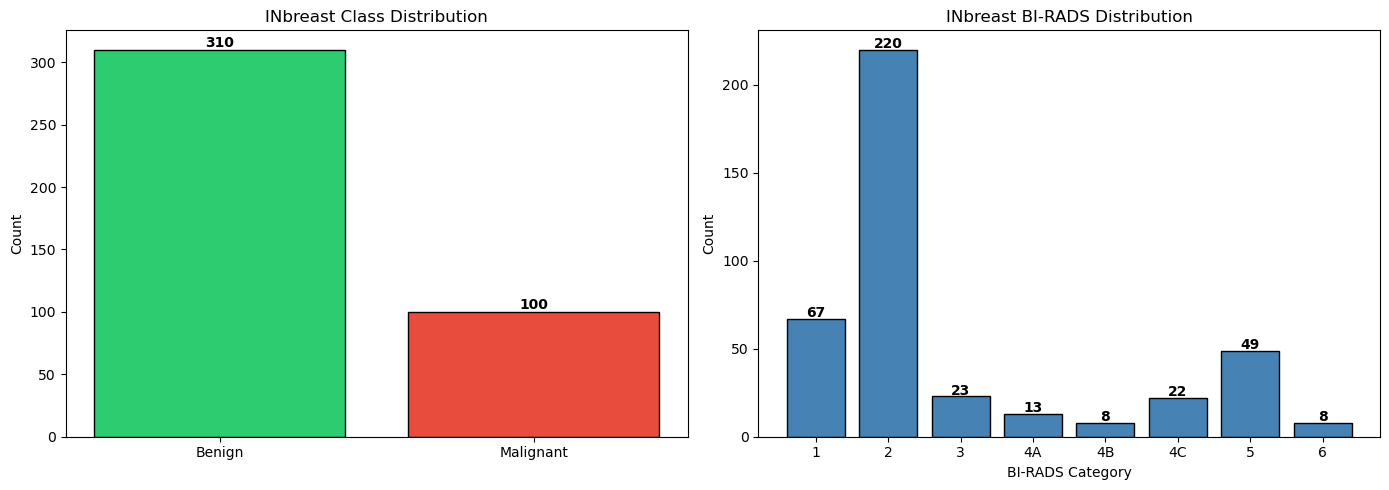

In [8]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = [stats.benign_count, stats.malignant_count]
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Benign', 'Malignant'], class_counts, color=colors, edgecolor='black')
axes[0].set_title('INbreast Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# BI-RADS distribution
if processed_records:
    birads_counts = defaultdict(int)
    for r in processed_records:
        birads_counts[r['birads']] += 1
    birads_sorted = sorted(birads_counts.items(), key=lambda x: x[0])
    birads_labels = [b[0].upper() for b in birads_sorted]
    birads_values = [b[1] for b in birads_sorted]
    axes[1].bar(birads_labels, birads_values, color='steelblue', edgecolor='black')
    axes[1].set_title('INbreast BI-RADS Distribution', fontsize=12)
    axes[1].set_ylabel('Count')
    axes[1].set_xlabel('BI-RADS Category')
    for i, v in enumerate(birads_values):
        axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Statistics

In [9]:
# Save preprocessing statistics
stats_dict = {
    'timestamp': datetime.now().isoformat(),
    'config': {
        'target_size': config.target_size,
        'clahe_clip_limit': config.clahe_clip_limit,
        'remove_artifacts': config.remove_artifacts,
        'apply_clahe': config.apply_clahe
    },
    'statistics': {
        'total_images': stats.total_images,
        'processed': stats.processed,
        'skipped': stats.skipped,
        'errors': stats.errors,
        'benign_count': stats.benign_count,
        'malignant_count': stats.malignant_count
    },
    'view_pairs': len(view_pairs_df) if view_pairs_df is not None else 0
}

stats_path = os.path.join(config.output_dir, 'inbreast_preprocessing_stats.json')
with open(stats_path, 'w') as f:
    json.dump(stats_dict, f, indent=2)

print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Pipeline: Artifact Removal + CLAHE + Resize({config.target_size})")
print(f"Total processed: {stats.processed}/{stats.total_images}")
print(f"Class distribution: Benign={stats.benign_count}, Malignant={stats.malignant_count}")
print(f"View pairs for multi-view: {len(view_pairs_df) if view_pairs_df is not None else 0}")
print(f"Output directory: {config.output_dir}")
print(f"Statistics saved to: {stats_path}")
print("=" * 60)


PREPROCESSING SUMMARY
Pipeline: Artifact Removal + CLAHE + Resize((768, 768))
Total processed: 410/410
Class distribution: Benign=310, Malignant=100
View pairs for multi-view: 2
Output directory: D:\Project\data\inbreast_preprocessed
Statistics saved to: D:\Project\data\inbreast_preprocessed\inbreast_preprocessing_stats.json
